Hands-On Lab: Sprint 2 Kickoff & Convolution        
● Step 1: Complete Sprint 2 planning and select the core-model backlog tasks.       
● Step 2: On a sample image, apply a hand-defined edge-detection filter with a convolution and visualize the feature map.       
● Step 3: Explain, in Markdown, why the same filter across the whole image needs far fewer weights than a dense layer.      
● Step 4: Confirm whether the project's data type calls for a CNN, RNN/Transformer, or the dense network from Week 6, and record the decision.      

#### Load & inspect Dataset:

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import tensorflow as tf


In [19]:
IMG_SIZE = 128
BATCH_SIZE = 32

data_path = Path(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\Sprint 2\Data")

print("Data folder exists:", data_path.exists())

Data folder exists: True


In [20]:
print("Folders inside Data:")

for folder in data_path.iterdir():
    if folder.is_dir():
        print(folder.name)

Folders inside Data:
Bag Classes


In [21]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

def contains_class_folders(folder):
    subfolders = [
        f for f in folder.iterdir()
        if f.is_dir()
    ]

    if len(subfolders) < 2:
        return False

    folders_with_images = 0

    for subfolder in subfolders:
        has_image = any(
            file.suffix.lower() in image_extensions
            for file in subfolder.rglob("*")
            if file.is_file()
        )

        if has_image:
            folders_with_images += 1

    return folders_with_images >= 2

In [22]:
dataset_path = None

folders_to_check = [data_path] + [
    folder
    for folder in data_path.rglob("*")
    if folder.is_dir()
]

for folder in folders_to_check:
    if contains_class_folders(folder):
        dataset_path = folder
        break

print("Dataset path:", dataset_path)

Dataset path: C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\Sprint 2\Data\Bag Classes


In [23]:
dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 15000 files belonging to 3 classes.


In [24]:
class_names = dataset.class_names

print("Classes:")
print(class_names)

print("Number of classes:", len(class_names))

Classes:
['Bag Classes', 'Paper Bag Images', 'Plastic Bag Images']
Number of classes: 3


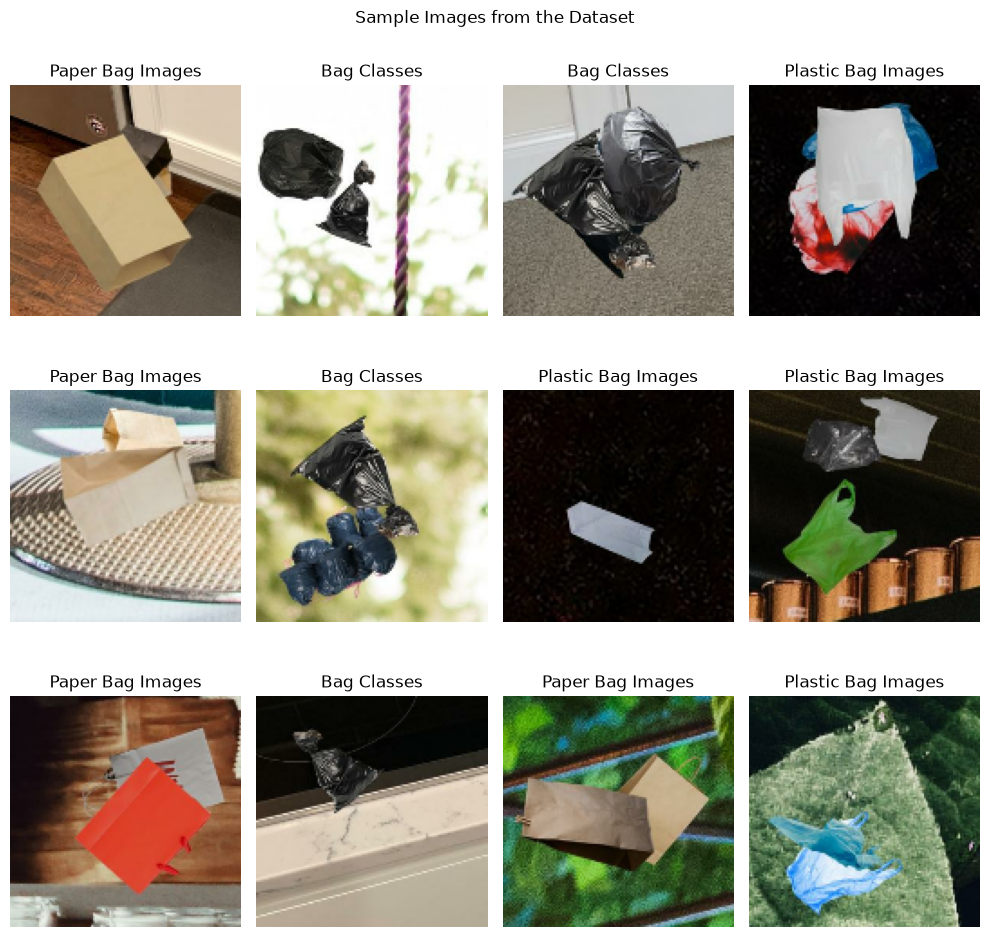

In [25]:
plt.figure(figsize=(10, 10))

for images, labels in dataset.take(1):

    for i in range(min(12, len(images))):

        plt.subplot(3, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i].numpy()]
        )

        plt.axis("off")

plt.suptitle("Sample Images from the Dataset")
plt.tight_layout()
plt.show()

In [26]:
print("Image count per class:")

for class_name in class_names:

    class_folder = dataset_path / class_name

    images = [
        file
        for file in class_folder.rglob("*")
        if file.is_file()
        and file.suffix.lower() in image_extensions
    ]

    print(
        f"{class_name}: {len(images)} images"
    )

Image count per class:
Bag Classes: 5000 images
Paper Bag Images: 5000 images
Plastic Bag Images: 5000 images


### CNN intro:


A CNN extracts visual patterns from images using small filters called kernels.  
The filter moves across the image and produces a **feature map** that shows where a certain pattern, such as an edge, is detected.

Below, a simple vertical edge-detection filter is applied manually to one image from the dataset.

#### Edge-detection filter:



The following `3×3` kernel is designed to detect **vertical edges**.

Negative and positive values on opposite sides of the filter respond strongly when there is a large change in pixel intensity from left to right.

##### 1- Get one sample image from the dataset:

In [27]:
# Get one image from the TensorFlow dataset

for images, labels in dataset.take(1):
    
    sample_image = images[0]
    sample_label = labels[0]

    break

print("Original image shape:", sample_image.shape)
print("Class:", class_names[sample_label.numpy()])

Original image shape: (128, 128, 3)
Class: Bag Classes


##### 2- Convert it to grayscale:

In [ ]:
# for the manual convolution,
# Convert the sample RGB image to grayscale,
# so the calculation stays simple.

image_array = tf.image.rgb_to_grayscale(sample_image)

# Remove the final channel dimension:
# (130, 130, 3) -rgb- --> (130, 130,1)  -greyscale-

image_array = tf.squeeze(image_array).numpy() # squeeze removes deimentions of size 1, (130, 130,1) -> (130, 130)

print("Grayscale image shape:", image_array.shape)

Grayscale image shape: (128, 128)


##### 3- Display the grayscale image:

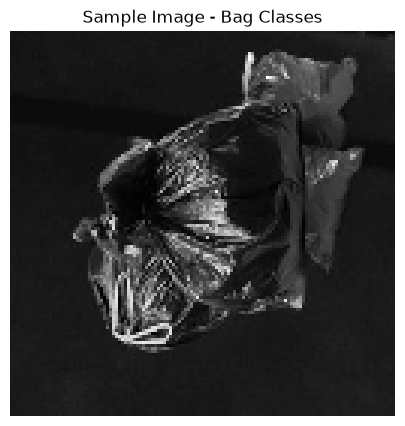

In [ ]:
# view selected image
plt.figure(figsize=(5, 5))

plt.imshow(image_array, cmap="gray")

plt.title( f"Sample Image - {class_names[sample_label.numpy()]}" )

plt.axis("off")

plt.show()
    

The selected image is converted to grayscale to simplify the manual convolution.

This leaves one intensity value for each pixel instead of three RGB channel values.

##### 4-  Define the vertical edge-detection kernel:

In [30]:
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

print(kernel)

[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]


##### 5- Prepare the output feature map:

In [ ]:
kernel_height, kernel_width = kernel.shape

image_height, image_width = image_array.shape

output_height = image_height - kernel_height + 1
output_width = image_width - kernel_width + 1

feature_map = np.zeros( (output_height, output_width) )

print("Input image shape:", image_array.shape)
print("Feature map shape:", feature_map.shape)

Input image shape: (128, 128)
Feature map shape: (126, 126)


##### 6-  Perform the convolution manually:

In [32]:
# manual convolution
for i in range(output_height):

    for j in range(output_width):

        region = image_array[
            i:i + kernel_height,
            j:j + kernel_width
        ]

        feature_map[i, j] = np.sum(
            region * kernel
        )


print("Input image shape:", image_array.shape)
print("Feature map shape:", feature_map.shape)

Input image shape: (128, 128)
Feature map shape: (126, 126)


The `3×3` filter slides across the image one pixel at a time.

At every position:

1. A `3×3` region of the image is selected.
2. Its values are multiplied by the kernel.
3. The values are summed.
4. The result becomes one value in the feature map.

Since no padding is used, the `128×128` image produces a `126×126` feature map.

##### 7-  Display original image vs feature map

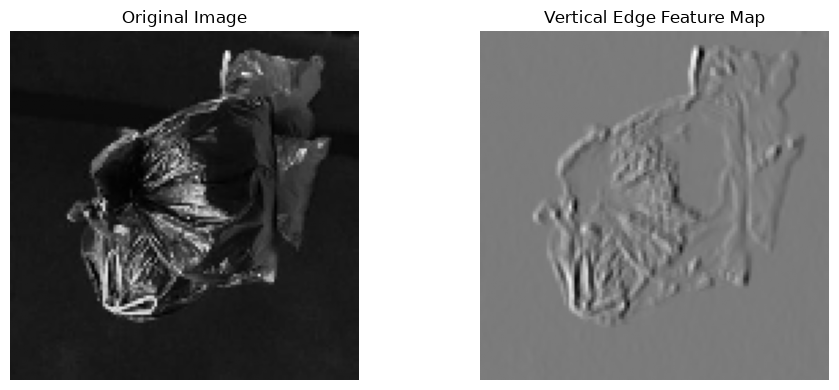

In [33]:
plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)

plt.imshow(
    image_array,
    cmap="gray"
)

plt.title("Original Image")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    feature_map,
    cmap="gray"
)

plt.title("Vertical Edge Feature Map")
plt.axis("off")


plt.tight_layout()
plt.show()

**Feature Map Interpretation**

The original image is shown on the left, while the result of the vertical edge filter is shown on the right.

The brighter and darker areas in the feature map represent locations where strong changes in pixel intensity were detected.

This demonstrates the basic idea of convolution: instead of using the raw pixels directly, CNNs learn filters that extract useful features such as edges, textures, and shapes.

##### 8- Parameter-sharing comparison:

In [ ]:
num_pixels = image_array.size

dense_neurons = 64

dense_parameters = (num_pixels * dense_neurons + dense_neurons)

cnn_kernel_parameters = kernel.size

print("Number of image pixels:", num_pixels)
print("Dense layer parameters:", dense_parameters)
print("Single 3x3 convolution filter parameters:", cnn_kernel_parameters)

Number of image pixels: 16384
Dense layer parameters: 1048640
Single 3x3 convolution filter parameters: 9


##### 9- print the ratio:

In [35]:
print(
    "Dense layer uses about",
    round(dense_parameters / cnn_kernel_parameters),
    "times more parameters than this single filter."
)

Dense layer uses about 116516 times more parameters than this single filter.


**Why Convolution Uses Fewer Parameters**

A dense layer creates separate connections between every input pixel and every neuron. For a 128×128 image connected to 64 neurons, this already requires more than one million parameters.

A 3×3 convolution filter uses only 9 weights for a grayscale image, and the same weights are reused across the image. This is called parameter sharing and makes CNNs much more efficient for image data.

#### Architecture decision:
   


**Core Architecture Decision**

The Sprint 2 dataset contains images of waste categories such as plastic, paper, and garbage bags.      
 Because images contain spatial relationships between nearby pixels, a Convolutional Neural Network (CNN) is appropriate for this task.     

CNNs can learn local visual patterns such as edges, shapes, and textures using convolutional filters.       
 Therefore, a CNN will be used as the core model for this sprint.       
  Later experiments will compare a CNN trained from scratch with data augmentation and transfer learning.    